# R2 - EMBED TESTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import jscatter
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns

#enable pandas tdqm
from tqdm import tqdm
tqdm.pandas()


In [3]:
%cd ..
%cd ..

f:\robusto\vqa_analysis


# LOADING DATA

In [26]:
#load from pickle
import pickle
def load_embeddings_cache(path):
    with open(path, "rb") as f:
        embeddings_cache = pickle.load(f)
    return embeddings_cache

#loaded embeddings cache is a dict of text to embedding
embedings_cache_path_test = "./external_embeds/qwen_batch1_r2_embeddings_cache_keyed.pkl"
emb_test = load_embeddings_cache(embedings_cache_path_test)
print(f"Loaded embeddings cache with {len(emb_test)} entries")
human_embedings = 0
vlm_embedings = 0
for key in emb_test.keys():
    #key is a tuple of agent video question answer
    if "human" in  key[0]:
        human_embedings += 1
        #print(f"Human embedding key: {key}")
    else:
        vlm_embedings += 1
        #print(f"VLM embedding key: {key}")
print(f"Human embedings: {human_embedings}")
print(f"VLM embedings: {vlm_embedings}")
print(f"Total embedings: {len(emb_test)}")

Loaded embeddings cache with 86000 entries
Human embedings: 6000
VLM embedings: 80000
Total embedings: 86000


In [27]:
#load answers text cache
answers_text_cache_path = "./data/r2_cleaned.csv"
df_answers = pd.read_csv(answers_text_cache_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers = df_answers[df_answers["REPETITION"] == 1].reset_index(drop=True)
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
print(f"Loaded answers text cache with {len(df_answers)} entries")
df_answers.head()

Loaded answers text cache with 10000 entries


,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC


In [28]:
#first reduce all embedding cache using pca to 2 dimensions and store then into a df with agent video question answer and embedding
def build_embeding_matrix(df_answers, embeddings_cache):
    embeddings = []
    for idx,row in df_answers.iterrows():
        key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])
        if key in embeddings_cache:
            embedding = embeddings_cache[key]
            embeddings.append(embedding)
            
        else:
            raise ValueError(f"Embedding for key {key} not found in cache")

    embeddings_arr = np.vstack(embeddings)
    return embeddings_arr
        
embeding_arr = build_embeding_matrix(df_answers, emb_test)
print(f"Embeddings array shape before PCA: {embeding_arr.shape}")
#center
mean_embedding = np.mean(embeding_arr, axis=0)
mean_embedding

Embeddings array shape before PCA: (10000, 2560)


array([-0.00017393, -0.00707671,  0.01617387, ...,  0.00508293,
        0.00868755,  0.00126765], shape=(2560,), dtype=float32)

# Testing

In [200]:
#write answers of yes no of question 7 and 6 with Yes No
df_to_dump = df_answers.copy()

#replace valus with samele of yes or no
print("Unique answers before replacement:", df_to_dump["QUESTION_NUM"].unique())
mask = (df_to_dump["QUESTION_NUM"].isin([6,7]))


def convert_to_yes_no(x):
    try:
        n = int(x)
        if n > 5:
            return "Yes"
        else:
            return "No"
    except ValueError:
        return "none"
df_to_dump.loc[mask,"ANSWER"] = df_to_dump.loc[mask,"ANSWER"].apply(convert_to_yes_no)

df_to_dump.to_csv("./data/r2_cleaned_boolean.csv", index=False)

Unique answers before replacement: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [199]:
df_to_dump[df_to_dump["ANSWER"] == "7"]

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR
108,human_lima_4,Robusto2_153,2,8,1,7,NYC
109,human_lima_5,Robusto2_153,2,8,1,7,NYC
112,human_lima_8,Robusto2_153,2,8,1,7,NYC
121,human_lima_2,Robusto2_153,2,9,1,7,NYC
133,human_nyc_14,Robusto2_153,2,9,1,7,NYC
...,...,...,...,...,...,...,...
9769,VideoLLaMA3-7B,Robusto2_69,2,10,1,7,LIMA
9868,VideoLLaMA3-7B,Robusto2_153,2,9,1,7,NYC
9869,VideoLLaMA3-7B,Robusto2_153,2,10,1,7,NYC
9908,VideoLLaMA3-7B,Robusto2_180,2,9,1,7,NYC


In [ ]:
embed_v1_index = df_answers[df_answers["ANSWER"] == "1"].head(4).index
embed_v2_index = df_answers[df_answers["ANSWER"] == "7"].head(4).index

embed_v1_r2 = embeddings_arr[embed_v1_index]
embed_v2_r2 = embeddings_arr[embed_v2_index]

for i in range(len(embed_v1_r2)):
        for j in range(len(embed_v2_r2)):
                dot_product = np.dot(embed_v1_r2[i], embed_v2_r2[j])
                print(f"Dot product of embed_v1_r2[{i}] and embed_v2_r2[{j}]: {dot_product}")


Dot product of embed_v1_r2[0] and embed_v2_r2[0]: 0.8615732192993164
Dot product of embed_v1_r2[0] and embed_v2_r2[1]: 0.8587020635604858
Dot product of embed_v1_r2[0] and embed_v2_r2[2]: 0.8587020635604858
Dot product of embed_v1_r2[0] and embed_v2_r2[3]: 0.8587020635604858
Dot product of embed_v1_r2[1] and embed_v2_r2[0]: 0.8615732192993164
Dot product of embed_v1_r2[1] and embed_v2_r2[1]: 0.8587020635604858
Dot product of embed_v1_r2[1] and embed_v2_r2[2]: 0.8587020635604858
Dot product of embed_v1_r2[1] and embed_v2_r2[3]: 0.8587020635604858
Dot product of embed_v1_r2[2] and embed_v2_r2[0]: 0.8615732192993164
Dot product of embed_v1_r2[2] and embed_v2_r2[1]: 0.8587020635604858
Dot product of embed_v1_r2[2] and embed_v2_r2[2]: 0.8587020635604858
Dot product of embed_v1_r2[2] and embed_v2_r2[3]: 0.8587020635604858
Dot product of embed_v1_r2[3] and embed_v2_r2[0]: 0.8615732192993164
Dot product of embed_v1_r2[3] and embed_v2_r2[1]: 0.8587020635604858
Dot product of embed_v1_r2[3] and 

In [201]:
df_answers_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_answers_r1 = df_answers_r1[df_answers_r1["REPETITION"] == 1].reset_index(drop=True) 

df_answers_r1[df_answers_r1["BLOCK"] == 2]["ANSWER"].unique()

<ArrowStringArray>
[      '3',     'Yes',       '1',       '0',      'No',     '2-3',       '5',
 '[Empty]',       '7',       '8',       '6',      'no',       '2',       '4',
     'yes',   '11-20',    '7-10',       '9',     '4-6',      '10',     '21+',
    'Yes'']
Length: 22, dtype: str

In [ ]:

with open("./external_embeds/embeddings_cache_keyed_qwen_r1_new.pkl", "rb") as f:
    embeddings_cache_r1 = pickle.load(f)

#build embed stack
    
embeddings_r1 = []
for idx,row in df_answers_r1.iterrows():
    key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION"])
    if key in embeddings_cache_r1:
        embedding = embeddings_cache_r1[key]
        embeddings_r1.append(embedding)
    else:
        raise ValueError(f"Embedding for key {key} not found in cache")

embeddings_arr_r1 = np.vstack(embeddings_r1)

embed_v1_index = df_answers_r1[df_answers_r1["ANSWER"] == "1"].head(4).index
embed_v2_index = df_answers_r1[df_answers_r1["ANSWER"] == "7"].head(4).index
print(f"Embed v1 index: {embed_v1_index}, Embed v2 index: {embed_v2_index}")

embed_v1_r1 = embeddings_arr_r1[embed_v1_index]
embed_v2_r1 = embeddings_arr_r1[embed_v2_index]

#get the dot product of each row
for i in range(len(embed_v1_r2)):
        for j in range(len(embed_v2_r2)):
                dot_product = np.dot(embed_v1_r1[i], embed_v2_r1[j])
                print(f"Dot product of embed_v1_r1[{i}] and embed_v2_r1[{j}]: {dot_product}")


In [115]:
with open("./test_embedding.pkl", "rb") as f:
    seven_embed = pickle.load(f)
    
np.dot(seven_embed, embed_v2_r2[0,:])

np.float32(1.0031377)

In [41]:
df_answers_r1[df_answers_r1["ANSWER"] == "7"]

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
129,deepseek_v2,Robusto 1_202,10,Q10,7,1,2
159,deepseek_v2,Robusto 1_204,10,Q10,7,1,2
189,deepseek_v2,Robusto 1_206,10,Q10,7,1,2
204,deepseek_v2,Robusto 1_207,10,Q10,7,1,2
230,gemini-2.0,Robusto 1_202,6,Q6,7,1,2
279,gemini-2.0,Robusto 1_205,10,Q10,7,1,2
290,gemini-2.0,Robusto 1_206,6,Q6,7,1,2
305,gemini-2.0,Robusto 1_207,6,Q6,7,1,2
309,gemini-2.0,Robusto 1_207,10,Q10,7,1,2
335,Humano1,Robusto 1_202,6,Q6: Please rate the level of clutter from 1 to...,7,1,2


In [48]:
np.dot(embed_v2_r1, embed_v2_r2)


np.float32(0.9977443)

In [139]:
#set all empty string to default 0 value
df_answers["ANSWER"] = df_answers["ANSWER"].replace("", "0")

In [349]:
df_answers_r2 = pd.read_csv("./data/r2_cleaned.csv", keep_default_na=False)
df_answers_r2[df_answers_r2["BLOCK"] == 2]["ANSWER"].unique()

<ArrowStringArray>
['4', '3', '5', '9', '7', '6', '8', '2', '10', '1', '']
Length: 11, dtype: str

# COSINE HEATMAPS

In [17]:
df_answers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AGENT         10000 non-null  str  
 1   VIDEO         10000 non-null  str  
 2   BLOCK         10000 non-null  int64
 3   QUESTION_NUM  10000 non-null  int64
 4   REPETITION    10000 non-null  int64
 5   ANSWER        10000 non-null  str  
 6   VIDEO_SECTOR  10000 non-null  str  
dtypes: int64(3), str(4)
memory usage: 1.5 MB


In [34]:
#GROUP THE data by bideo sector
KEYS = ["VIDEO","BLOCK", "QUESTION_NUM","VIDEO_SECTOR","AGENT","REPETITION"]
df_comp = pd.merge(df_answers[KEYS], df_answers[KEYS], on=["VIDEO","BLOCK","QUESTION_NUM","VIDEO_SECTOR"], suffixes=('_I', '_J')) 
df_comp.head(5)

,VIDEO,BLOCK,QUESTION_NUM,VIDEO_SECTOR,AGENT_I,REPETITION_I,AGENT_J,REPETITION_J
0,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_1,1
1,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_2,1
2,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_3,1
3,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_4,1
4,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_5,1


In [81]:
#now compute the cosine thingy here
def comparation_func(row : list, cache : list):
    key_i = (row["AGENT_I"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION_I"])
    key_j = (row["AGENT_J"], row["VIDEO"], row["QUESTION_NUM"], row["REPETITION_J"])
    
    embed_i = cache.get(key_i, None)
    embed_j = cache.get(key_j, None)
    
    if embed_i is None or embed_j is None:
        raise ValueError(f"Embedding not found for keys: {key_i}, {key_j}")
    
    embed_i = embed_i - mean_embedding
    embed_j = embed_j - mean_embedding
    
    dot_product = np.dot(embed_i, embed_j)
    norm_i = np.linalg.norm(embed_i)
    norm_j = np.linalg.norm(embed_j)
    if norm_i == 0 or norm_j == 0:
        return 0.0
    cosine_similarity = dot_product / (norm_i * norm_j)
    return cosine_similarity
    
    #compute euclidean distance
    # distance = 1 - np.linalg.norm(embed_i - embed_j) * 0.5
    return distance

df_comp["RESULT"] = df_comp.progress_apply(lambda row: comparation_func(row, embeddings_cache), axis=1)

100%|██████████| 250000/250000 [00:05<00:00, 43109.17it/s]


In [119]:
df_comp_answers = df_comp

#now merge the result with each video question agent_i and agent_j to get the answer_i and answer_j
df_comp_answers = pd.merge(df_comp_answers, df_answers[["VIDEO","QUESTION_NUM","AGENT","ANSWER"]], left_on=["VIDEO","QUESTION_NUM","AGENT_I"], right_on=["VIDEO","QUESTION_NUM","AGENT"], how="left").drop(columns=["AGENT"])
df_comp_answers = pd.merge(df_comp_answers, df_answers[["VIDEO","QUESTION_NUM","AGENT","ANSWER"]], left_on=["VIDEO","QUESTION_NUM","AGENT_J"], right_on=["VIDEO","QUESTION_NUM","AGENT"], how="left", suffixes=('_I', '_J')).drop(columns=["AGENT"])
df_comp_answers.head(5)


,VIDEO,BLOCK,QUESTION_NUM,VIDEO_SECTOR,AGENT_I,REPETITION_I,AGENT_J,REPETITION_J,RESULT,ANSWER_I,ANSWER_J
0,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_1,1,1.000000,The ego vehicle is accelerating slowly because...,The ego vehicle is accelerating slowly because...
1,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_2,1,0.352418,The ego vehicle is accelerating slowly because...,The ego vehicle is turning to the right
2,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_3,1,0.343795,The ego vehicle is accelerating slowly because...,the ego vehicle brakes and steers slightly to ...
3,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_4,1,0.218134,The ego vehicle is accelerating slowly because...,Braking to yield
4,Robusto2_153,1,1,NYC,human_lima_1,1,human_lima_5,1,0.465869,The ego vehicle is accelerating slowly because...,The ego vehicle is moving forward while mainta...


In [82]:
agg_df = (
    df_comp
    .groupby(
        ["VIDEO","BLOCK", "QUESTION_NUM","VIDEO_SECTOR", "AGENT_I", "AGENT_J"],
        as_index=False
    )["RESULT"].mean()
)

agg_df = (
    agg_df
    .groupby(
        ["VIDEO_SECTOR","BLOCK", "AGENT_I", "AGENT_J"],
        as_index=False
    )["RESULT"]
    .mean()
)

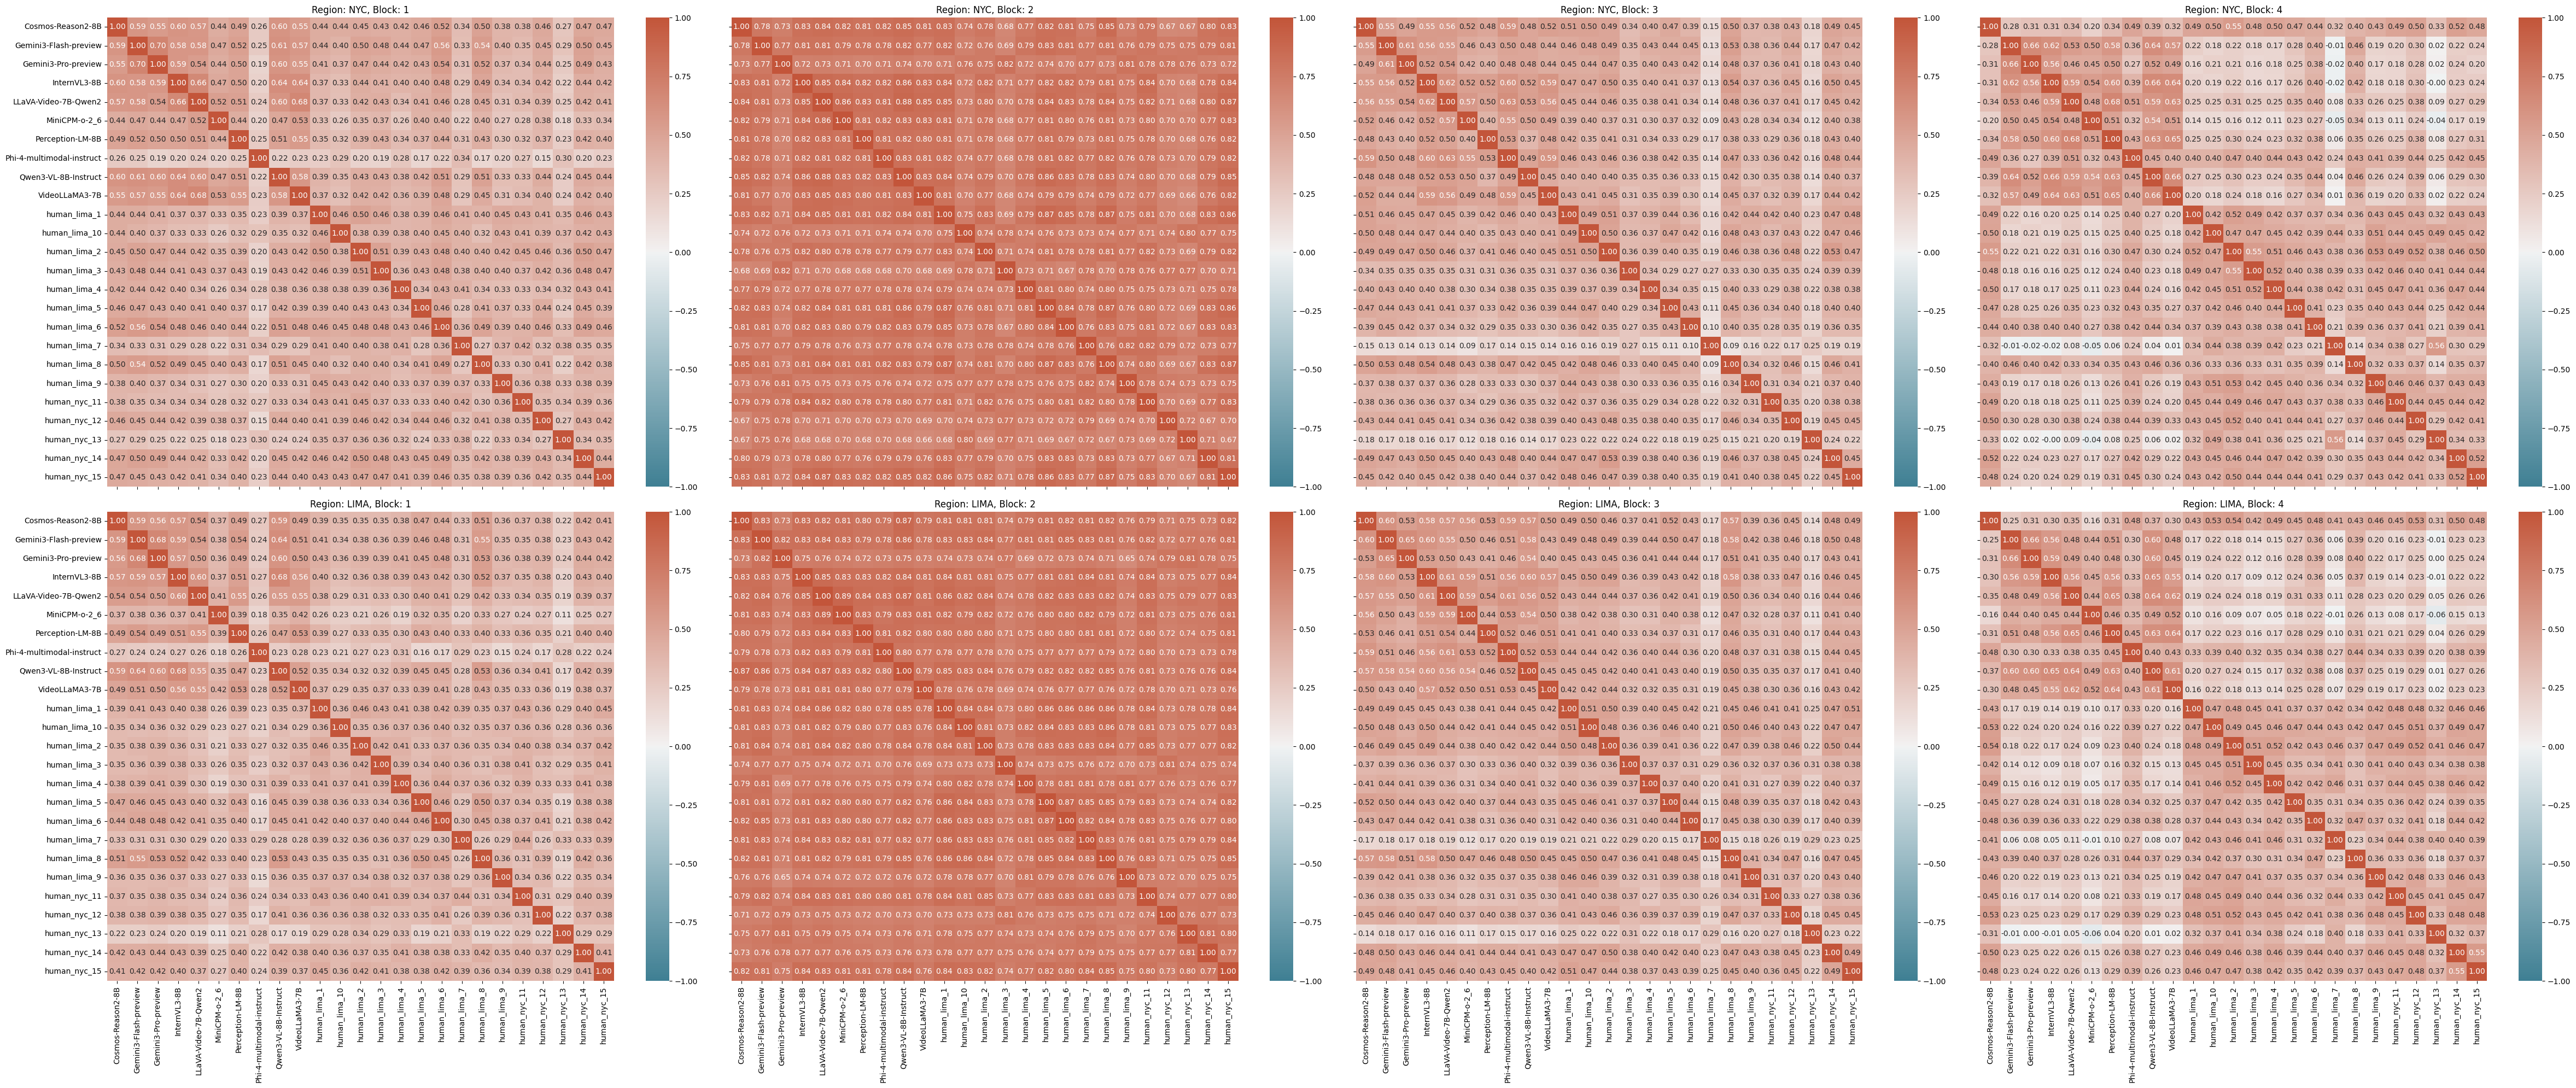

In [117]:
nrows = 2
ncols = 4
fig, ax = plt.subplots(nrows, ncols, figsize=(12 * ncols, 10  * nrows),sharex=True,sharey=True)

c = sns.diverging_palette(220, 20, as_cmap=True)
for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
    for block in df_answers["BLOCK"].astype(int).unique():
        df_block = agg_df[(agg_df["VIDEO_SECTOR"] == region) & (agg_df["BLOCK"] == block)]
        pivot_table = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="RESULT")
        values = pivot_table.to_numpy()
        sns.heatmap(values, cmap=c, ax=ax[id_r, block-1], vmin=-1, vmax=1,xticklabels=pivot_table.columns, yticklabels=pivot_table.columns, annot=True, fmt=".2f")
        ax[id_r, block-1].set_title(f"Region: {region}, Block: {block}")
fig.tight_layout()

In [118]:
fig.savefig("./heatmaps_r2.png")

# RSA ANALYSIS

In [110]:
from scipy.stats import pearsonr,spearmanr
CHANGE_BLOCK = True

def compute_rsa_matrices(df_answers, embeddings_arr, corr_func = spearmanr):
    agents = df_answers["AGENT"].unique()
    vlms = [agent for agent in agents if "Humano" not in agent]
    humans = [agent for agent in agents if "Humano" in agent]

    agents = vlms + humans

    rsas = {}
    gramians = {}
    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            print(f"Processing region {region} block {block}")
            #product the gramian matrix of all t embeds of block 
            for agent in agents:
                mask = (df_answers["AGENT"] == agent) & (df_answers["VIDEO_SECTOR"] == region) & (df_answers["BLOCK"] == block)
                df_selected = df_answers[mask] #.sort_values(by=["VIDEO", "QUESTION_NUM", "REPETITION"])
                selected_embeddings = embeddings_arr[df_selected.index]
                
                #compute the gramian matrix
                if block != 2 or CHANGE_BLOCK:
                    selected_embeddings = selected_embeddings / np.linalg.norm(selected_embeddings, axis=1, keepdims=True)
                    gramian_matrix = selected_embeddings @ selected_embeddings.T
                    gramians[(agent,block,region)] = gramian_matrix
                else:
                    r_col = df_selected["ANSWER"].astype(int).to_numpy()
                    gramians[(agent,block,region)] = r_col

            #RSA    
            rsa_matrix = np.zeros((len(agents), len(agents)))
            for i, agent_i in enumerate(agents):
                for j, agent_j in enumerate(agents):
                    if i <= j:
                        #compute the correlation between the two gramian matrices
                        gramian_i = gramians[(agent_i,block,region)]
                        gramian_j = gramians[(agent_j,block,region)]

                        if block != 2 or CHANGE_BLOCK:
                            triu_indices = np.triu_indices_from(gramian_i, k=1)
                            gj_upper = gramian_j[triu_indices]
                            gi_upper = gramian_i[triu_indices]
                        else:
                            gj_upper = gramian_j
                            gi_upper = gramian_i
                            
                        correlation,_ = corr_func(gi_upper, gj_upper)
                        rsa_matrix[i, j] = correlation
                        rsa_matrix[j, i] = correlation
                        rsas[(region, block)] = rsa_matrix
    return rsas, gramians, agents
                            
def plot_rsa_matrices(rsas, agents, title):
    nrows = 2
    ncols = 4
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),sharex=True,sharey=True)

    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            rsa_matrix = rsas[(region, block)]
            sns.heatmap(rsa_matrix, annot=False, xticklabels=agents, yticklabels=agents, cmap=c, ax=c_ax,square=True, vmin=-1, vmax=1,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
    fig.tight_layout()
    fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)
    
def check_gramians(gramians, agent, region):
    fig,ax = plt.subplots(1,5, figsize=(20,4))
    fig.suptitle(f"Matrices of Gramian {agent} | {region}", fontsize=24, weight="bold")
    ax = ax.flatten()
    
    for i in range(1,4):
        gemini = gramians[(agent,i,region)]
        sns.heatmap(gemini * gemini.T,cmap="viridis", vmin=-1, vmax=1,ax=ax[i-1],square=True)
        ax[i-1].set_title(f"Block {i}", fontsize=16)
    fig.tight_layout()

In [123]:
def make_rsa_analysis(df_answers, cache_path, corr_func = pearsonr):
    emdeds_cache = load_embeddings_cache(cache_path)
    embeds_matrix = build_embeding_matrix(df_answers, emdeds_cache)
    rsas,gramians,agents = compute_rsa_matrices(df_answers, embeds_matrix, corr_func=corr_func)
    #hacky way to get the name 
    #get the file name without extension
    file_name = os.path.basename(cache_path)
    args = file_name.split("_")
    embed = args[0]
    batch = args[1]
    dataset = args[2]
    print("Plotting RSA matrices...")
    plot_rsa_matrices(rsas, agents, f"RSA analysis - Embed {embed} - {batch} - Func {corr_func.__name__} - Dataset {dataset}")

## RSA Allmpnet - Batch 1 - Spearman

Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
Processing region NYC block 4
Processing region LIMA block 1
Processing region LIMA block 2
Processing region LIMA block 3
Processing region LIMA block 4
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed allmpnet - batch1 - Func pearsonr - Dataset r2 as rsa_output_rsa_analysis_-_embed_allmpnet_-_batch1_-_func_pearsonr_-_dataset_r2.png


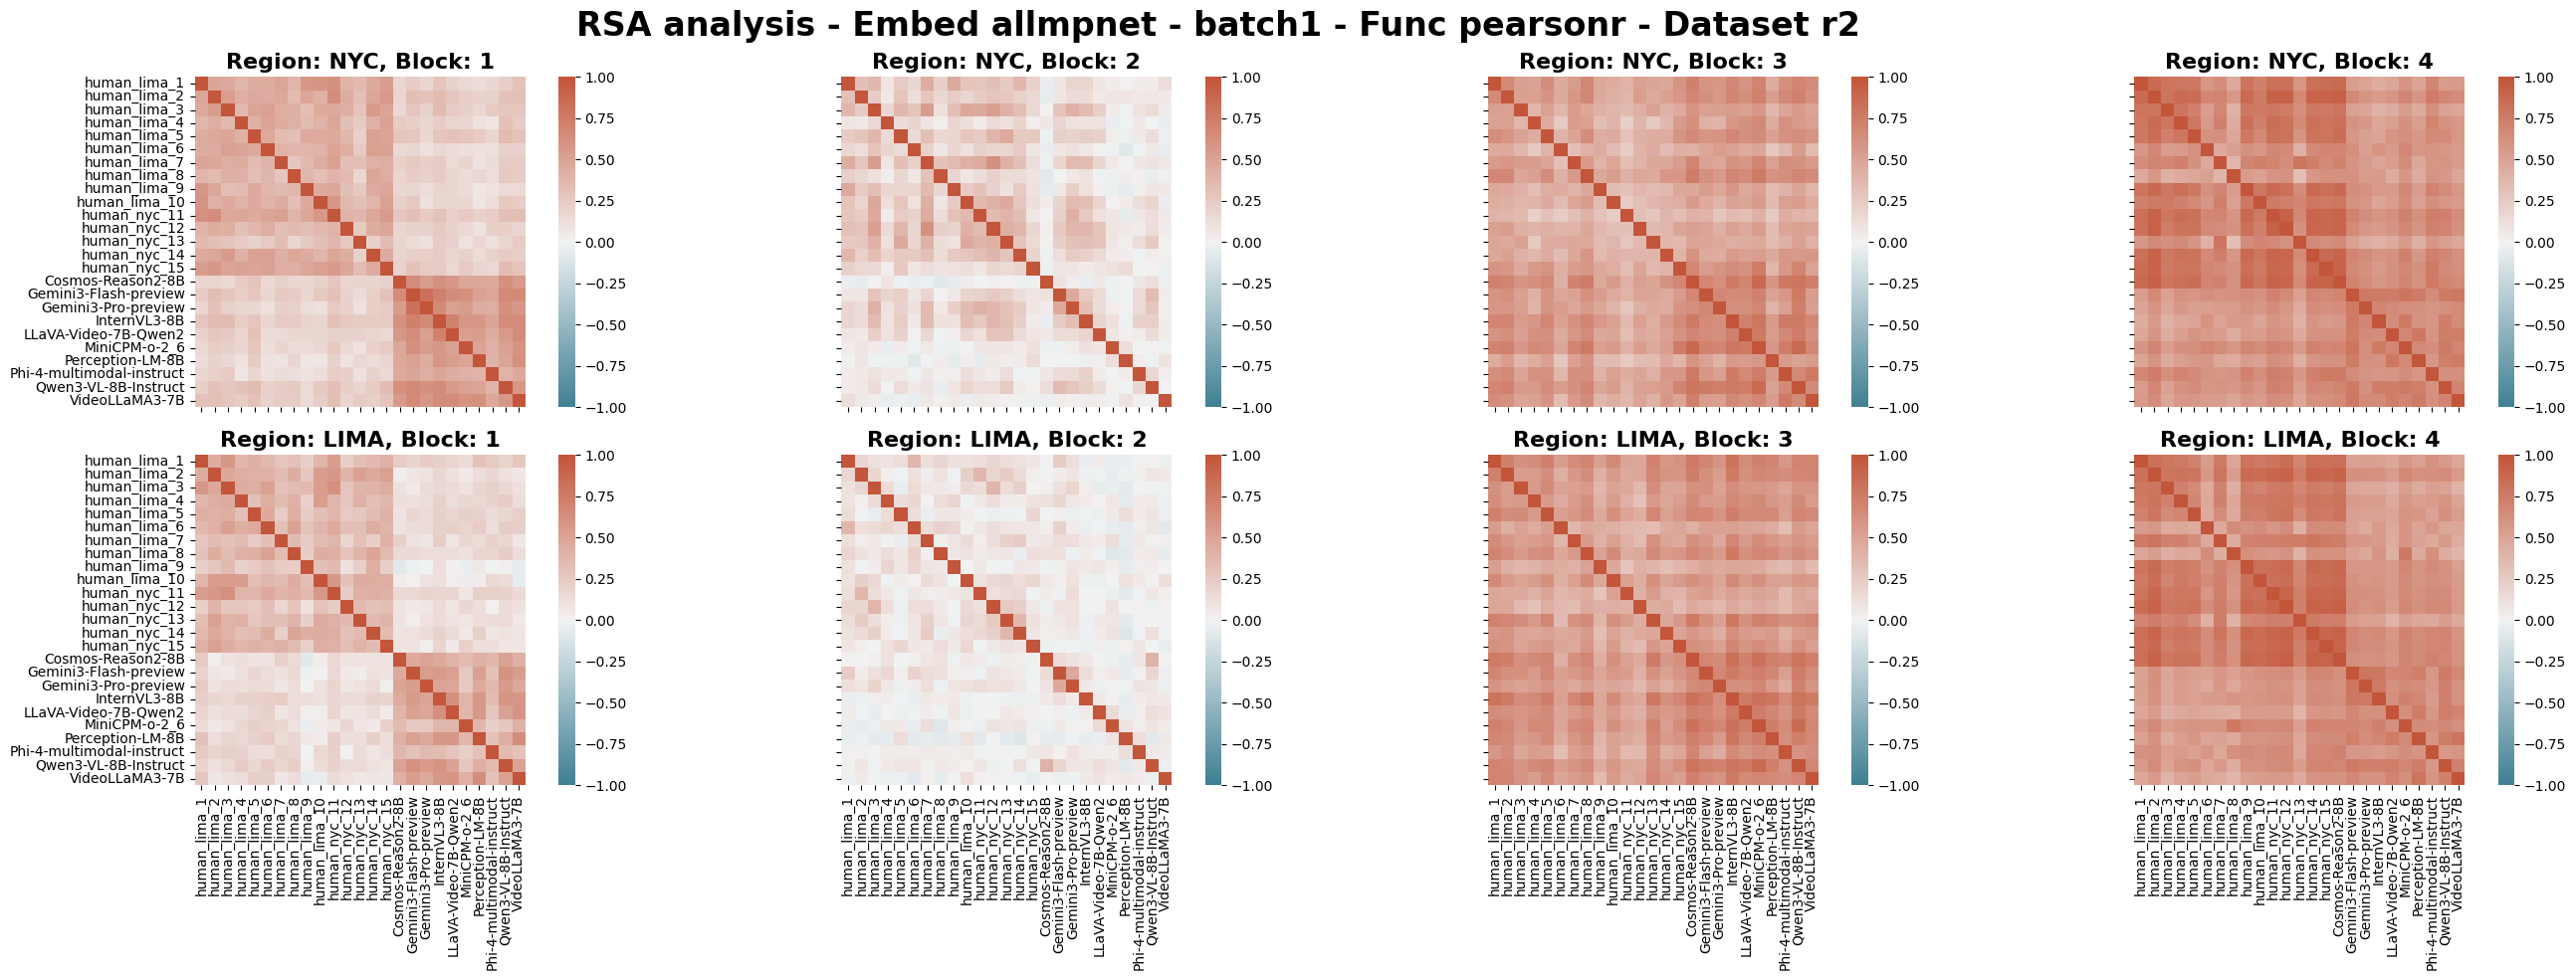

In [62]:
path = "./external_embeds/allmpnet_batch1_r2_embeddings_cache_keyed.pkl"
make_rsa_analysis(df_answers,path, corr_func=pearsonr)

## RSA Qwen - Batch 1 - Pearson

Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
Processing region NYC block 4
Processing region LIMA block 1
Processing region LIMA block 2
Processing region LIMA block 3
Processing region LIMA block 4
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed qwen - batch1 - Func pearsonr - Dataset r2 as rsa_output_rsa_analysis_-_embed_qwen_-_batch1_-_func_pearsonr_-_dataset_r2.png


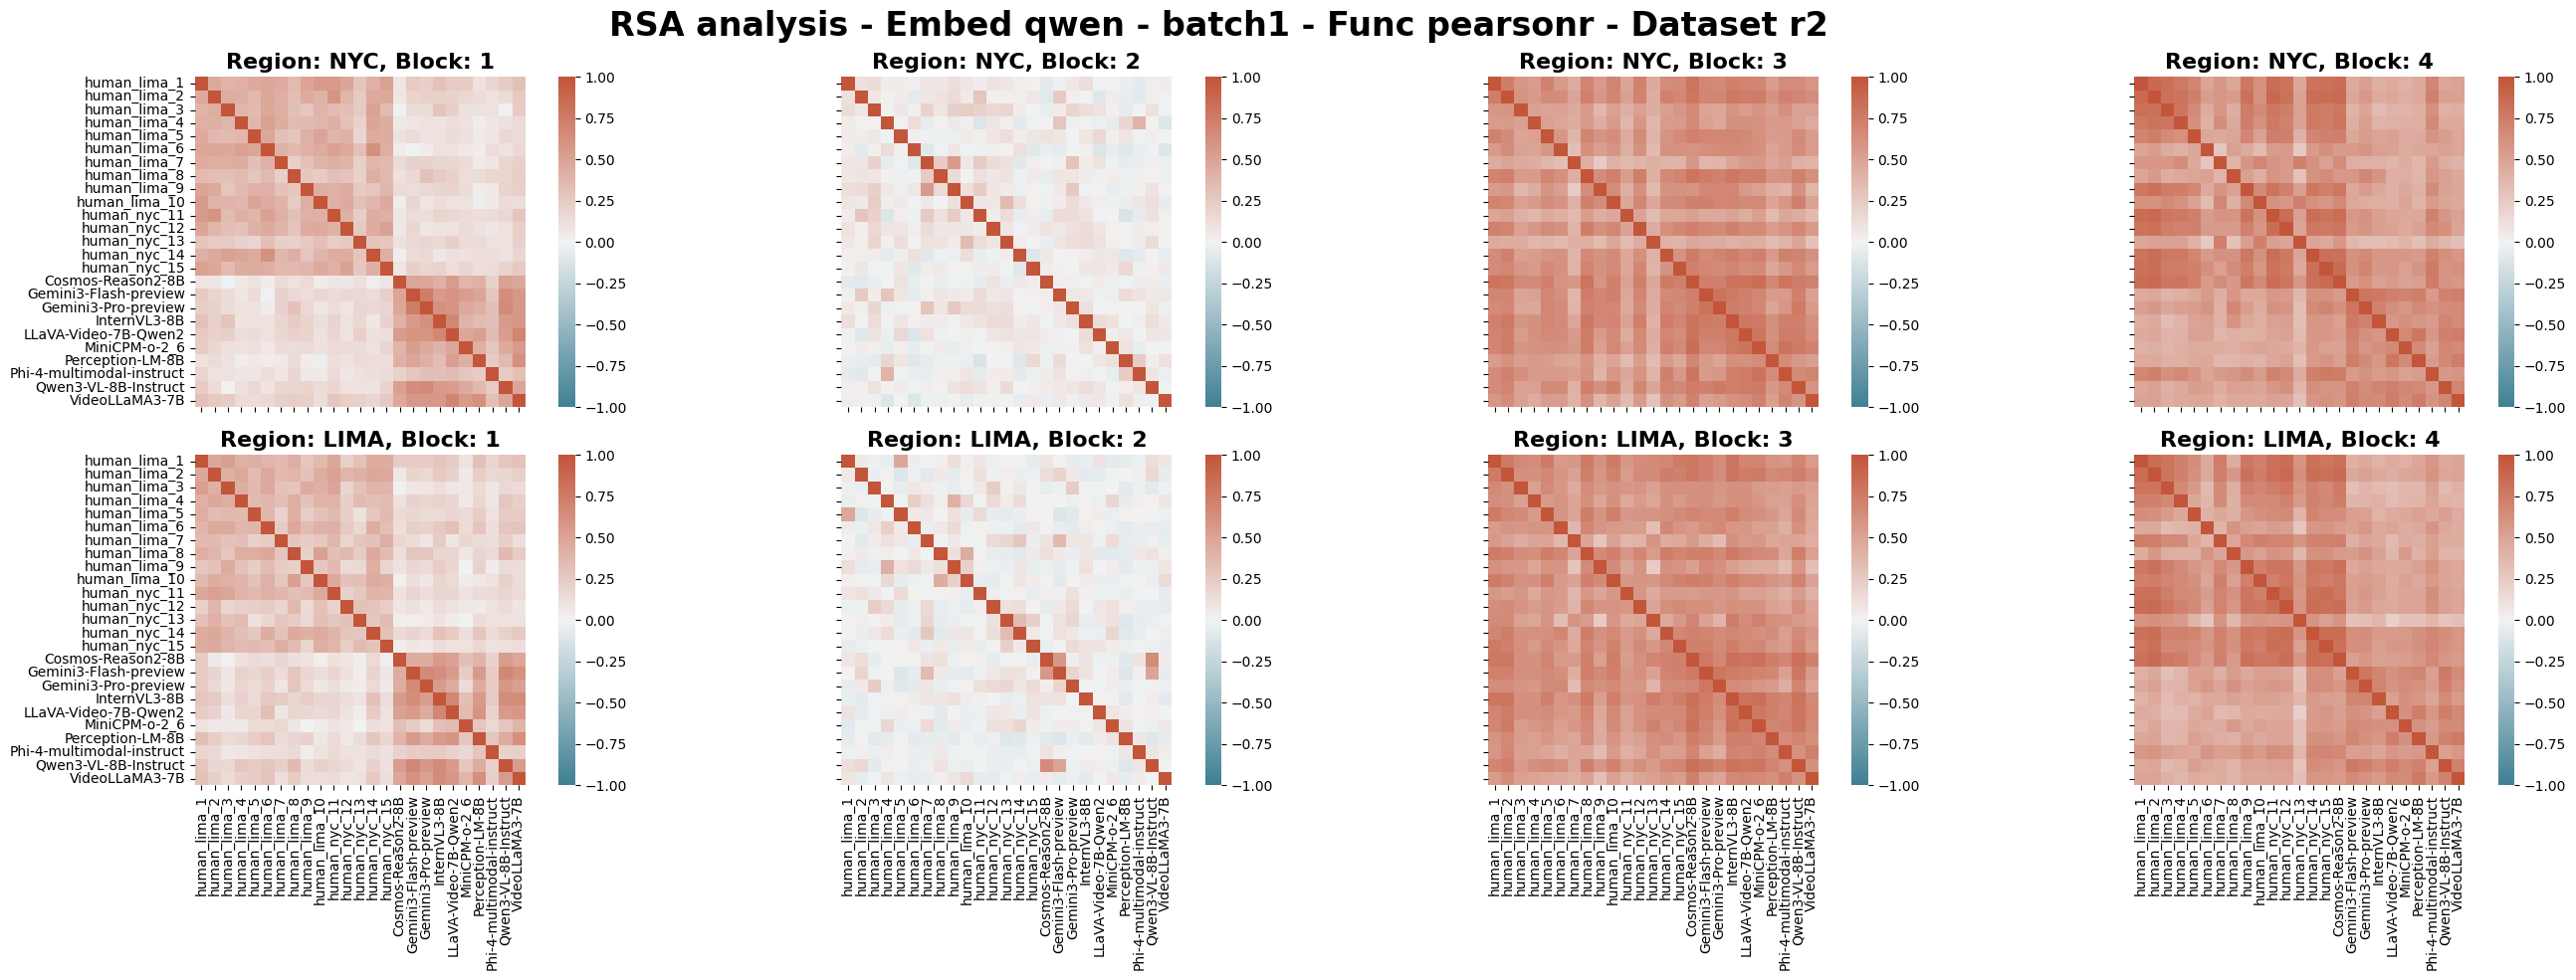

In [63]:
path = "./external_embeds/qwen_batch1_r2_embeddings_cache_keyed.pkl"
make_rsa_analysis(df_answers,path, corr_func=pearsonr)

## R1 - REPRODUCTION

In [149]:
ORDER_AGENTS = [
    'cogvlm2',     # El camaleón de visual help
    'qwen2',       # El logo geométrico de Alibaba
    'gemini-2.0',  # La G de Google
    'pixtral',     # El logo de Mistral (la H estilizada)
    'Llama-3.2',   # El logo de Meta
    'deepseek_v2'  # La ballena
]

#JOIN THE HUMANS
ORDER_AGENTS = ORDER_AGENTS + [f"Humano{i}" for i in range(1, 10)]
ORDER_AGENTS

['cogvlm2',
 'qwen2',
 'gemini-2.0',
 'pixtral',
 'Llama-3.2',
 'deepseek_v2',
 'Humano1',
 'Humano2',
 'Humano3',
 'Humano4',
 'Humano5',
 'Humano6',
 'Humano7',
 'Humano8',
 'Humano9']

In [155]:
from scipy.stats import pearsonr,spearmanr
CHANGE_BLOCK = True
def compute_rsa_matrices(df_answers, embeddings_arr, corr_func = spearmanr):
    #agents = df_answers["AGENT"].unique()
    #vlms = [agent for agent in agents if "Humano" not in agent]
    #humans = [agent for agent in agents if "Humano" in agent]

    agents = ORDER_AGENTS #vlms + humans

    rsas = {}
    gramians = {}
    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            print(f"Processing region {region} block {block}")
            #product the gramian matrix of all t embeds of block 
            for agent in agents:
                mask = (df_answers["AGENT"] == agent) & (df_answers["VIDEO_SECTOR"] == region) & (df_answers["BLOCK"] == block)
                df_selected = df_answers[mask] #.sort_values(by=["VIDEO", "QUESTION_NUM", "REPETITION"])
                selected_embeddings = embeddings_arr[df_selected.index]
                
                #compute the gramian matrix
                selected_embeddings = selected_embeddings / np.linalg.norm(selected_embeddings, axis=1, keepdims=True)
                gramian_matrix = selected_embeddings @ selected_embeddings.T
                gramians[(agent,block,region)] = gramian_matrix
            #RSA    
            rsa_matrix = np.zeros((len(agents), len(agents)))
            for i, agent_i in enumerate(agents):
                for j, agent_j in enumerate(agents):
                    if i <= j:
                        #compute the correlation between the two gramian matrices
                        gramian_i = gramians[(agent_i,block,region)]
                        gramian_j = gramians[(agent_j,block,region)]
                        triu_indices = np.triu_indices_from(gramian_i, k=1)
                        gj_upper = gramian_j[triu_indices]
                        gi_upper = gramian_i[triu_indices]
                        correlation,_ = corr_func(gi_upper, gj_upper)
                        rsa_matrix[i, j] = correlation
                        rsa_matrix[j, i] = correlation
                        rsas[(region, block)] = rsa_matrix
    return rsas, gramians, agents
                            
def plot_rsa_matrices(df_answers,rsas, agents, title):
    nrows = len(df_answers["VIDEO_SECTOR"].unique())
    ncols = len(df_answers["BLOCK"].astype(int).unique())
    
    fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows),sharex=True,sharey=True)
    ax = ax.reshape(nrows, ncols)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()):
        for block in df_answers["BLOCK"].astype(int).unique():
            c_ax = ax[id_r,block - 1]
            rsa_matrix = rsas[(region, block)]
            sns.heatmap(rsa_matrix, annot=True, xticklabels=agents, yticklabels=agents, cmap=c, ax=c_ax,square=True, vmin=-1, vmax=1,annot_kws={"fontsize":6}, fmt=".2f")
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
    fig.tight_layout()
    fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)

    
def remove_repetitions_by_mean_embeds(df_answers, embeddings_cache):
    #the embebedings dictionary cache has keys of the form (agent, video, question_num, repetition) and values of the form embedding vector
    #we want to remove the repetition dimension by averaging the embeddings of the same agent, video and question_num
    mean_embedding_cache = {}
    #group by agent video question_num and average the embeddings
    #remore the rows where the answer where is empty string or [Empty]
    print(f"Input shape of answers df: {df_answers.shape}")
    df_answers = df_answers.copy()[~df_answers["ANSWER"].isin(["", "[Empty]"])].reset_index(drop=True)
    print(f"Removed empty answers, new shape of answers df: {df_answers.shape}")

    grouped = df_answers.groupby(["AGENT", "VIDEO", "QUESTION_NUM"])
    #iterate over the groups and average the embeddings
    for agent, video, question_num in grouped.groups.keys():
        group_indices = grouped.groups[(agent, video, question_num)]
        embeddings = []
        for repetition in df_answers.loc[group_indices, "REPETITION"]:
            #Check if answer value if not [Empty]
            key = (agent, video, question_num, repetition)
            if key in embeddings_cache:
                embeddings.append(embeddings_cache[key])
            else:
                raise ValueError(f"Embedding for key {key} not found in cache")
        mean_embedding = np.mean(embeddings, axis=0)
        mean_embedding_cache[(agent, video, question_num)] = mean_embedding
        
    #now remove the reptitions from the df_answers
    mean_answers_df = grouped.first().reset_index()
    print(f"Removed repetitions, new shape of answers df: {mean_answers_df.shape}")
    return mean_answers_df, mean_embedding_cache

def build_embeding_matrix(df_answers, embeddings_cache):
    embeddings = []
    for idx,row in df_answers.iterrows():
        key = (row["AGENT"], row["VIDEO"], row["QUESTION_NUM"])
        if key in embeddings_cache:
            embedding = embeddings_cache[key]
            embeddings.append(embedding)
        else:
            raise ValueError(f"Embedding for key {key} not found in cache")

    embeddings_arr = np.vstack(embeddings)
    return embeddings_arr
    
def make_rsa_analysis(df_answers, cache_path, corr_func = pearsonr):
    emdeds_cache = load_embeddings_cache(cache_path)
    df_answers_no_reps, mean_embedding_cache = remove_repetitions_by_mean_embeds(df_answers, emdeds_cache)
    embeds_matrix = build_embeding_matrix(df_answers_no_reps,mean_embedding_cache)
    rsas,gramians,agents = compute_rsa_matrices(df_answers_no_reps, embeds_matrix, corr_func=corr_func)
    print(rsas.keys())
    #hacky way to get the name 
    #get the file name without extension
    file_name = os.path.basename(cache_path)
    args = file_name.split("_")
    embed = args[0]
    batch = args[1]
    dataset = args[2]
    print("Plotting RSA matrices...")
    plot_rsa_matrices(df_answers, rsas, agents, f"RSA analysis - Embed {embed} - {batch} - Func {corr_func.__name__} - Dataset {dataset}")

Input shape of answers df: (6405, 8)
Removed empty answers, new shape of answers df: (6294, 8)
Removed repetitions, new shape of answers df: (1575, 8)
Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
dict_keys([('NYC', np.int64(1)), ('NYC', np.int64(2)), ('NYC', np.int64(3))])
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed allmpnet - batch1 - Func pearsonr - Dataset r1 as rsa_output_rsa_analysis_-_embed_allmpnet_-_batch1_-_func_pearsonr_-_dataset_r1.png


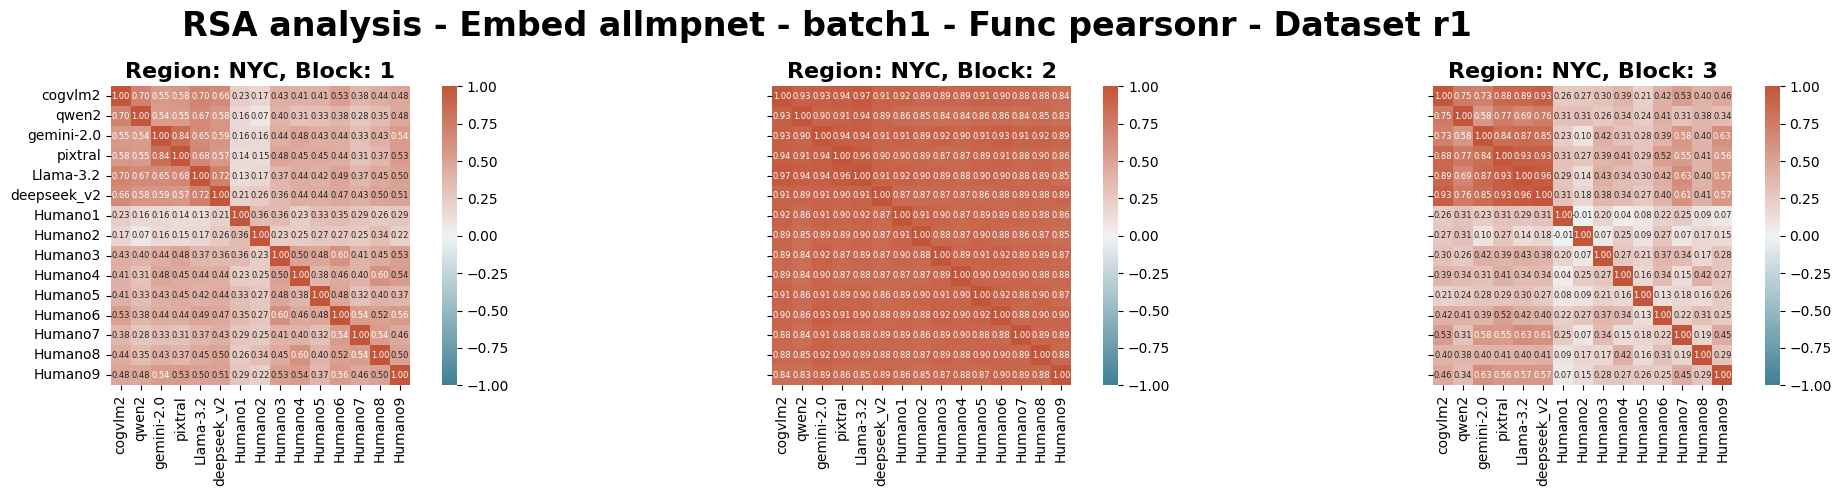

In [156]:
df_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_r1["VIDEO_SECTOR"] = df_r1["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
make_rsa_analysis(df_r1,"./external_embeds/allmpnet_batch1_r1_embeddings_cache_keyed.pkl", corr_func=pearsonr)

Removed repetitions, new shape of answers df: (1575, 8)
Processing region NYC block 1
Processing region NYC block 2
Processing region NYC block 3
dict_keys([('NYC', np.int64(1)), ('NYC', np.int64(2)), ('NYC', np.int64(3))])
Plotting RSA matrices...
Saving RSA plot with title: RSA analysis - Embed allmpnet - batch64 - Func pearsonr - Dataset r1 as rsa_output_rsa_analysis_-_embed_allmpnet_-_batch64_-_func_pearsonr_-_dataset_r1.png


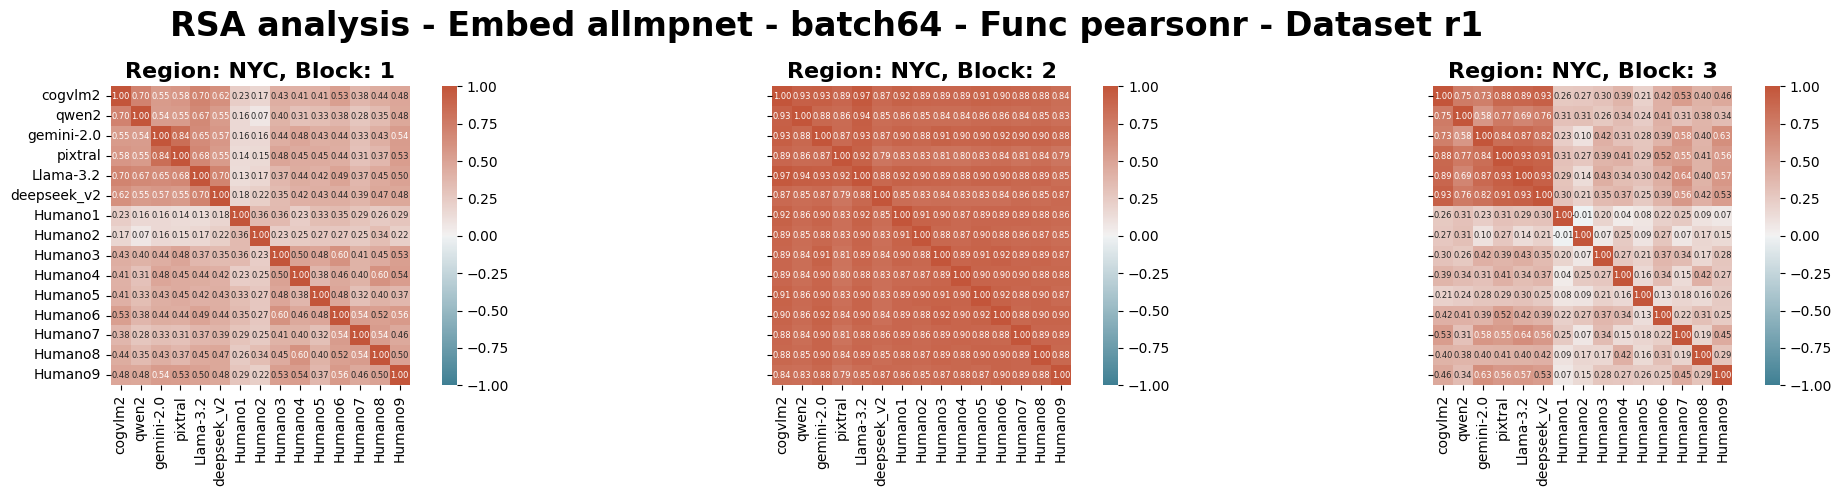

In [152]:
df_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_r1["VIDEO_SECTOR"] = df_r1["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")
make_rsa_analysis(df_r1,"./external_embeds/allmpnet_batch64_r1_embeddings_cache_keyed.pkl", corr_func=pearsonr)

# EMBED ANALYSIS

In [73]:
coords_PCA = np.zeros((len(df_answers), 2))
coords_UMAP = np.zeros((len(df_answers), 2))

embd_test = load_embeddings_cache("./external_embeds/allmpnet_batch1_r2_embeddings_cache_keyed.pkl")
embeddings_arr = build_embeding_matrix(df_answers, emb_test)

print("Starting dimensionality reduction by blocks...")
for block in [1, 2, 3, 4]:
    mask = df_answers["BLOCK"] == block
    print(f"Processing block {block} with {mask.sum()} entries")
    if mask.any():
        pca_block = PCA(n_components=2)
        #umap_block = UMAP(n_components=2, random_state=42)
        coords_PCA[mask.values] = pca_block.fit_transform(embeddings_arr[mask.values])
        #coords_UMAP[mask.values] = umap_block.fit_transform(embeddings_arr[mask.values])

Starting dimensionality reduction by blocks...
Processing block 1 with 2500 entries
Processing block 2 with 2500 entries
Processing block 3 with 2500 entries
Processing block 4 with 2500 entries


In [76]:
import src.config
interactive = df_answers.assign(pca_X=coords_PCA[:, 0], pca_Y=coords_PCA[:, 1])
interactive = interactive.assign(umap_X=coords_UMAP[:, 0], umap_Y=coords_UMAP[:, 1])
def get_group_color(agent):
    if "human" in agent:
        if "nyc" in agent:
            return "nyc"
        else:
            return "lima"
    else:
        return "vlm"
    
color_map = {
    "nyc": src.config.PLOT_COLORS["HUMAN_NYC"], # Cian neón (sustituye al azul oscuro que no se ve)
    "lima": src.config.PLOT_COLORS["HUMAN_LIMA"], # Naranja-Rojo vibrante
    "vlm": src.config.PLOT_COLORS["VLM"], # Verde eléctrico (el que ya tienes, funciona bien)
}

interactive["group"] = interactive["AGENT"].map(get_group_color)
interactive.group

0       lima
1       lima
2       lima
3       lima
4       lima
        ... 
9995     vlm
9996     vlm
9997     vlm
9998     vlm
9999     vlm
Name: group, Length: 10000, dtype: str

## Embeds by old pipeline - Cleaned  - PCA reduced

In [68]:
import pandas as pd
import numpy as np

BLOCK_TO_PLOT = int(input("Enter the block number to plot (1-4): "))
df_block = interactive[interactive["BLOCK"] == BLOCK_TO_PLOT].copy().reset_index(drop=True)
# Sample data
# Create an interactive scatter plot
scatterA = jscatter.Scatter(
    data= df_block,  # Filter for block 1
    x='pca_X',
    y='pca_Y',
    color_by='group',
    color_map=color_map,
    opacity=0.9,
    background_color="#000000",
    axes = True,
    title=f"PCA Scatter Plot for Block {BLOCK_TO_PLOT}",
    tooltip=True,
    height=600,
    tooltip_preview= "ANSWER",
    tooltip_preview_type="text",
    tooltip_properties=["pca_X","pca_Y","AGENT", "VIDEO", "QUESTION_NUM"],
    tooltip_histograms_size="large",
    tooltip_size="medium"
)
scatterA.axes(labels=['PCA 1', 'PCA 2'])

scatterB = jscatter.Scatter(
    data= df_block,  # Filter for block 1
    x='umap_X',
    y='umap_Y',
    color_by='group',
    color_map=color_map,
    opacity=0.9,
    background_color="#000000",
    axes = True,
    title=f"PCA Scatter Plot for Block {BLOCK_TO_PLOT}",
    tooltip=True,
    tooltip_preview= "ANSWER",
    tooltip_preview_type="text",
    tooltip_properties=["umap_X","umap_Y","AGENT", "VIDEO", "QUESTION_NUM"],
    tooltip_histograms_size="large",
    tooltip_size="medium"
)
scatterB.axes(labels=['UMAP 1', 'UMAP 2'])


print(f"Displaying scatter plot  of Block {BLOCK_TO_PLOT}...")
# jscatter.link([scatterA, scatterB],row_height = 640)
scatterA.selection(df_block.query("ANSWER == '4'").index)
jscatter.link([scatterA, scatterB], row_height=640)

Displaying scatter plot  of Block 2...


GridBox(children=(VBox(children=(HBox(children=(VBox(children=(<jscatter.widgets.button.Button object at 0x000…

In [60]:
scatterA.selection(df_block.query("group == 'lima'").index)

In [23]:
indexs = scatterA.selection()
print(f"Selected indices: {len(indexs)}")
for i in indexs:
    print(df_block.iloc[i,5].encode())

Selected indices: 9
b'4'
b'4'
b'4'
b'4'
b'4'
b'4'
b'4'
b'4'
b'4'


# FINAL PLOTS

In [77]:
#assign region to each point in the scatter plot based on the video sector
#rule to check video sector Robusto2_XXX => if int(XXX) <= 100 => Lima else NYC

interactive["VIDEO_SECTOR"] = interactive["VIDEO"].apply(lambda x: "Lima" if int(x.split("_")[1]) <= 100 else "NYC")
interactive

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR,pca_X,pca_Y,umap_X,umap_Y,group
0,human_lima_1,Robusto2_153,1,1,1,The ego vehicle is accelerating slowly because...,NYC,-0.285813,-0.021686,0.0,0.0,lima
1,human_lima_2,Robusto2_153,1,1,1,The ego vehicle is turning to the right,NYC,-0.199985,0.042229,0.0,0.0,lima
2,human_lima_3,Robusto2_153,1,1,1,the ego vehicle brakes and steers slightly to ...,NYC,-0.224134,-0.002498,0.0,0.0,lima
3,human_lima_4,Robusto2_153,1,1,1,Braking to yield,NYC,-0.082399,-0.004632,0.0,0.0,lima
4,human_lima_5,Robusto2_153,1,1,1,The ego vehicle is moving forward while mainta...,NYC,-0.169618,-0.043864,0.0,0.0,lima
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,VideoLLaMA3-7B,Robusto2_195,4,16,1,"The yellow taxi has the right of way, as it is...",NYC,-0.215593,0.323752,0.0,0.0,vlm
9996,VideoLLaMA3-7B,Robusto2_195,4,17,1,The video does not provide information on pede...,NYC,-0.293275,-0.147000,0.0,0.0,vlm
9997,VideoLLaMA3-7B,Robusto2_195,4,18,1,The probability of a crash occurring in the mo...,NYC,0.020715,0.034171,0.0,0.0,vlm
9998,VideoLLaMA3-7B,Robusto2_195,4,19,1,There is one pedestrian present in the scene.,NYC,-0.089084,-0.327290,0.0,0.0,vlm


In [ ]:
import src.config 
def plot_by_block(df: pd.DataFrame) -> None:
    """Create PCA plots separated by block and video sector."""
    print("\n=== PCA by Block and Sector ===")
    
    for block in sorted(df["BLOCK"].unique()):
        # Fit PCA once per block with ALL videos (Lima + NYC)
        block_mask = df["BLOCK"] == block
        df_block = df[block_mask]
        
        print(f"Block {block}: Fitting PCA with {len(df_block)} total samples")
        
        #get min,max of embeddings_2d_block for consistent axis limits
        min_x, max_x = df[:, "pca_x"].min(), df[:,"pca_x"].max()
        min_y, max_y = df[:, "pca_y"].min(), df[:, "pca_y"].max()    

        # Now plot each sector separately in the same embedding space
        for sector in ['Lima', 'NYC']:
            sector_mask = df_block["VIDEO_SECTOR"] == sector
            embeddings_2d = df.loc[df['BLOCK'] == block, ['pca_x', 'pca_y']].to_numpy()
            df_subset = df_block[sector_mask]
            
            print(f"  {sector}: {len(df_subset)} samples")
            
            if len(df_subset) < 1:
                print(f"    Skipping (no data)")
                continue
            # Collect handles for grouped legend
            handles_vlm = []
            handles_lima = []
            handles_nyc = []
            
            # Plot VLMs (orange tones)
            for agent in config.VLM_AGENTS:
                if agent in df_subset["AGENT"].values:
                    agent_mask = df_subset["AGENT"] == agent
                    mask_array = agent_mask.values
                    
                    scatter = ax.scatter(
                        embeddings_2d[mask_array, 0],
                        embeddings_2d[mask_array, 1],
                        color=config.PLOT_COLORS["VLM"],
                        marker=config.AGENT_MARKERS_MAP[agent],
                        label=agent,
                        alpha=0.7,
                        s=60,
                        edgecolors='black',
                        linewidth=0.5
                    )
                    handles_vlm.append(scatter)
            
            # Plot Lima humans (light blue tones)
            for agent in config.LIMA_AGENTS:
                if agent in df_subset["AGENT"].values:
                    agent_mask = df_subset["AGENT"] == agent
                    mask_array = agent_mask.values
                    scatter = ax.scatter(
                        embeddings_2d[mask_array, 0],
                        embeddings_2d[mask_array, 1],
                        color=config.PLOT_COLORS["HUMAN_LIMA"],
                        marker=config.AGENT_MARKERS_MAP[agent],
                        label=agent,
                        alpha=0.7,
                        s=60,
                        edgecolors='black',
                        linewidth=0.5
                    )
                    handles_lima.append(scatter)
            
            # Plot NYC humans (dark blue tones)
            for agent in config.NYC_AGENTS:
                if agent in df_subset["AGENT"].values:
                    agent_mask = df_subset["AGENT"] == agent
                    mask_array = agent_mask.values
                    scatter = ax.scatter(
                        embeddings_2d[mask_array, 0],
                        embeddings_2d[mask_array, 1],
                        color=config.PLOT_COLORS["HUMAN_NYC"],
                        marker=config.AGENT_MARKERS_MAP[agent],
                        label=agent,
                        alpha=0.7,
                        s=60,
                        edgecolors='black',
                        linewidth=0.5
                    )
                    handles_nyc.append(scatter)
            
            # Create grouped legend: VLMs | GRUPO LIMA | GRUPO NYC
            all_handles = []
            all_labels = []

            if handles_vlm:
                all_handles.append(plt.Line2D([0], [0], marker='o', color='w', label='━━━ VLMs ━━━',
                                             markerfacecolor=config.PLOT_COLORS["VLM"], markersize=0, linestyle='None'))
                all_labels.append('━━━ VLMs ━━━')
                for h in handles_vlm:
                    all_handles.append(h)
                    all_labels.append(h.get_label())

            if handles_lima:
                all_handles.append(plt.Line2D([0], [0], marker='o', color='w', label='━━━ LIMA HUMANS ━━━',
                                             markerfacecolor=config.PLOT_COLORS["HUMAN_LIMA"], markersize=0, linestyle='None'))
                all_labels.append('━━━ LIMA HUMANS ━━━')
                for h in handles_lima:
                    all_handles.append(h)
                    all_labels.append(h.get_label())

            if handles_nyc:
                all_handles.append(plt.Line2D([0], [0], marker='o', color='w', label='━━━ NYC HUMANS ━━━',
                                             markerfacecolor=config.PLOT_COLORS["HUMAN_NYC"], markersize=0, linestyle='None'))
                all_labels.append('━━━ NYC HUMANS ━━━')
                for h in handles_nyc:
                    all_handles.append(h)
                    all_labels.append(h.get_label())

            ax.set_title(f"PCA - Block {block} - Videos {sector} (Q{(block-1)*5+1}-Q{block*5})", 
                        fontsize=config.PLOT_CONFIG["title_fontsize"], fontweight="bold")
            ax.set_xlabel(f"PCA1 ", fontsize=11)
            ax.set_ylabel(f"PCA2 ", fontsize=11)
            ax.legend(all_handles, all_labels, loc="center left", bbox_to_anchor=(1, 0.5), 
                     frameon=True, fontsize=config.PLOT_CONFIG["legend_fontsize"], ncol=1)
            ax.grid(True, alpha=0.3)
            
            # add a little padding to the limits for better visualization
            x_padding = (max_x - min_x) * 0.05
            y_padding = (max_y - min_y) * 0.05
            ax.set_xlim(min_x - x_padding, max_x + x_padding)
            ax.set_ylim(min_y - y_padding, max_y + y_padding)            

In [78]:
#show empty answers
df_empty_answers = interactive[interactive["ANSWER"] == ""]
df_empty_answers

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR,pca_X,pca_Y,umap_X,umap_Y,group
8445,Perception-LM-8B,Robusto2_37,2,6,1,,Lima,-0.150873,-0.027814,0.0,0.0,vlm
8725,Perception-LM-8B,Robusto2_181,2,6,1,,NYC,-0.150873,-0.027814,0.0,0.0,vlm


In [79]:
#now remove those with empty answers and plot again
interactive_non_empty = interactive[interactive["ANSWER"] != ""]
interactive_non_empty[interactive_non_empty["ANSWER"] == ""]

,AGENT,VIDEO,BLOCK,QUESTION_NUM,REPETITION,ANSWER,VIDEO_SECTOR,pca_X,pca_Y,umap_X,umap_Y,group


In [96]:
import src.config
import seaborn as sns

def plot_by_block_sector(df: pd.DataFrame, title : str) -> None:
    """
    Crea un grid de scatter plots (matriz) donde las filas son los sectores (Lima, NYC)
    y las columnas son los bloques (1-4). Todas las subplots comparten la misma ventana de dimensiones.
    Se añade una leyenda global a la derecha y cada punto tiene su símbolo según config.AGENT_MARKERS_MAP.
    Incluye líneas de grilla en cada subplot.
    """
    
    print("\n=== PCA por Block y Sector (Grid) ===")
    sectores = ['Lima', 'NYC']
    bloques = sorted(df["BLOCK"].unique())
    n_rows = len(sectores)
    n_cols = len(bloques)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharex=True, sharey=True)
    if n_rows == 1 or n_cols == 1:
        axes = axes.reshape((n_rows, n_cols))
    # Calcular límites globales
    min_x = df["pca_X"].min()
    max_x = df["pca_X"].max()
    min_y = df["pca_Y"].min()
    max_y = df["pca_Y"].max()
    x_padding = (max_x - min_x) * 0.05
    y_padding = (max_y - min_y) * 0.05
    min_x -= x_padding
    max_x += x_padding
    min_y -= y_padding
    max_y += y_padding
    # Para leyenda global
    handles_dict = {}
    for i, sector in enumerate(sectores):
        for j, block in enumerate(bloques):
            ax = axes[i, j]
            block_mask = df["BLOCK"] == block
            sector_mask = df["VIDEO_SECTOR"] == sector
            df_subset = df[block_mask & sector_mask]
            if len(df_subset) < 1:
                ax.set_title(f"Block {block} - {sector}\n(Sin datos)")
                ax.axis('off')
                continue
            # Graficar cada agente con su símbolo
            for agent in df_subset["AGENT"].unique():
                agent_mask = df_subset["AGENT"] == agent
                marker = src.config.AGENT_MARKERS_MAP.get(agent, 'o')
                group = df_subset[agent_mask]["group"].iloc[0]
                color = color_map[group]
                sc = ax.scatter(
                    df_subset[agent_mask]["pca_X"],
                    df_subset[agent_mask]["pca_Y"],
                    label=agent,
                    marker=marker,
                    color=color,
                    alpha=0.7,
                    edgecolors='black',
                    s=30,
                    linewidth=0.5
                )
                # Guardar handle para leyenda global
                if agent not in handles_dict:
                    handles_dict[agent] = sc
            ax.set_title(f"Block {block} - {sector}", weight="bold", fontsize=14)
            ax.set_xlabel("PC 1")
            ax.set_ylabel("PC 2")
            ax.set_xlim(min_x, max_x)
            ax.set_ylim(min_y, max_y)
            ax.grid(True, alpha=0.3)  # Añadir grid lines
    fig.legend(
        handles=list(handles_dict.values()),
        labels=list(handles_dict.keys()),
        loc='center right',
        frameon=True,
        bbox_to_anchor=(1.03, 0.5),
        fontsize=12,
        title_fontproperties={'weight': 'bold','size': 14},
        title="Agent"
    )
    
    fig.suptitle(title, fontsize=24, weight="bold")
    return fig, axes


In [97]:
#test plot giving a ax with a df to plot
import src.config
def plot_embeds(df_answers, embeddings_arr,title):
    coords_PCA = np.zeros((len(df_answers), 2))
    coords_UMAP = np.zeros((len(df_answers), 2))
    print("Starting dimensionality reduction by blocks...")
    for block in [1, 2, 3, 4]:
        mask = df_answers["BLOCK"] == block
        print(f"Processing block {block} with {mask.sum()} entries")
        if mask.any():
            pca_block = PCA(n_components=2)
            #umap_block = UMAP(n_components=2, random_state=42)
            coords_PCA[mask.values] = pca_block.fit_transform(embeddings_arr[mask.values])

    interactive = df_answers.assign(pca_X=coords_PCA[:, 0], pca_Y=coords_PCA[:, 1])
    interactive = interactive.assign(umap_X=coords_UMAP[:, 0], umap_Y=coords_UMAP[:, 1])
    def get_group_color(agent):
        if "human" in agent:
            if "nyc" in agent:
                return "nyc"
            else:
                return "lima"
        else:
            return "vlm"
        
    interactive["group"] = interactive["AGENT"].map(get_group_color)
    interactive["VIDEO_SECTOR"] = interactive["VIDEO"].apply(lambda x: "Lima" if int(x.split("_")[1]) <= 100 else "NYC")
    interactive_non_empty = interactive[interactive["ANSWER"] != ""]
    fig, r = plot_by_block_sector(interactive_non_empty,title)

    #save it to svg
    fig.savefig("./pca_by_block_sector.svg", bbox_inches='tight')


Embeddings array shape: (10000, 768)
Starting dimensionality reduction by blocks...
Processing block 1 with 2500 entries
Processing block 2 with 2500 entries
Processing block 3 with 2500 entries
Processing block 4 with 2500 entries

=== PCA por Block y Sector (Grid) ===


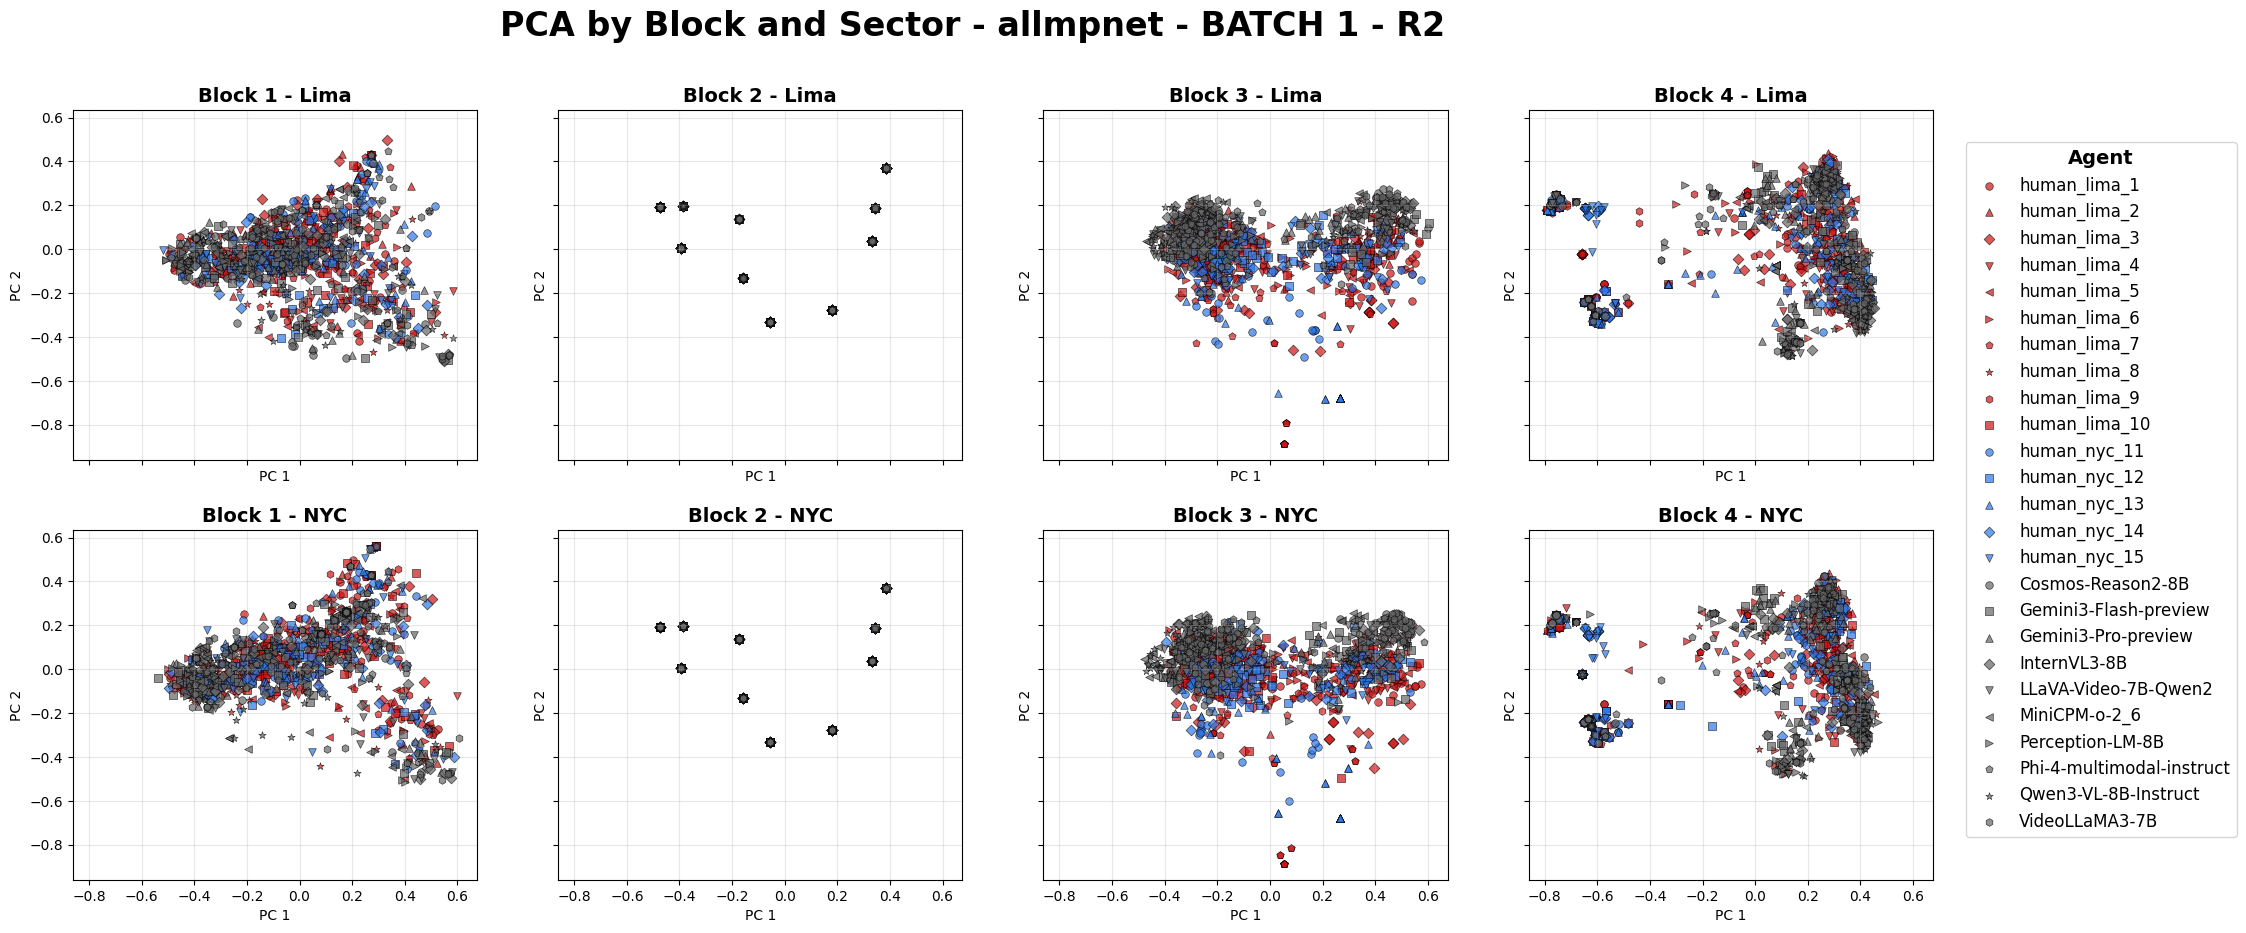

In [102]:
emb_test = load_embeddings_cache("./external_embeds/allmpnet_batch1_r2_embeddings_cache_keyed.pkl")
embeddings_arr = build_embeding_matrix(df_answers, emb_test)
print(f"Embeddings array shape: {embeddings_arr.shape}")
plot_embeds(df_answers, embeddings_arr,"PCA by Block and Sector - allmpnet - BATCH 1 - R2")

In [105]:
df_r1 = pd.read_csv("./data/r1_cleaned.csv", keep_default_na=False)
df_r1

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
0,cogvlm2,Robusto 1_201,1,Q1: What driving action is taking place?,The driving action in the video is a car driving.,1,1
1,cogvlm2,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,There is no interaction with other vehicles in...,1,1
2,cogvlm2,Robusto 1_201,3,Q3: What is the weather and road condition?,The weather and road condition in the video ar...,1,1
3,cogvlm2,Robusto 1_201,4,Q4: Is there any traffic light present?,"Yes, there is a traffic light present in the v...",1,1
4,cogvlm2,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,The traffic flow in the scene is congested.,1,1
...,...,...,...,...,...,...,...
6400,qwen2,Robusto 1_207,11,Q11: What would have had to happen in this vid...,The driver could have been distracted by somet...,1,3
6401,qwen2,Robusto 1_207,12,Q12: What would have had to happen in this vid...,The external crash would have involved another...,1,3
6402,qwen2,Robusto 1_207,13,Q13: What would have happened in the scene if ...,"If I had done the opposite action, I would hav...",1,3
6403,qwen2,Robusto 1_207,14,Q14: What would be the next action to perform ...,"If the driver were driving an ambulance, they ...",1,3
